In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Actual_Data_Final.csv")
print(df.head())
print(df.shape)

  Lead_ID Region      State        Course Time_Slot Pitch_Category  \
0  L00001  South  Karnataka    Full Stack   Evening           Long   
1  L00002  North     Punjab         Cloud   Morning          Short   
2  L00003   East  Jharkhand    Full Stack   Morning         Medium   
3  L00004   West        Goa  Data Science   Evening           Long   
4  L00005   East      Bihar         Cloud   Evening         Medium   

   Pitch_Minutes Followup_Gap  Script_Tone  Attempts  Lag   ELT  \
0           11.0       2 Days       Casual         1  3.6  15.0   
1            2.3       2 Days  Semi-Formal         2  5.0  11.7   
2            5.9     Same Day       Formal         1  3.7  14.4   
3            9.4     Same Day       Casual         1  2.4  12.0   
4            6.1        1 Day       Formal         1  4.4  14.9   

       Outreach_Type  Engagement_Score  Lead_Score  High_Engagement  \
0  Campus Ambassador                54          55                0   
1             Direct              

In [23]:
data = df.copy()
categorical_cols = [
    "Region",
    "State",
    "Course",
    "Time_Slot",
    "Pitch_Category",
    "Followup_Gap",
    "Script_Tone",
    "Outreach_Type"
]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

In [24]:
features = [
    "Region",
    "Course",
    "Time_Slot",
    "Pitch_Category",
    "Pitch_Minutes",
    "Followup_Gap",
    "Script_Tone",
    "Attempts",
    "Lag",
    "ELT",
    "Outreach_Type","Lead_Score","Conversion_Probability"
]
X = data[features]
y = data["High_Engagement"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print("Precision:",
      precision_score(y_test,y_pred_lr))

print("Recall:",
      recall_score(y_test,y_pred_lr))

print("F1:",
      f1_score(y_test,y_pred_lr))

Accuracy: 0.88
Precision: 0.8679653679653679
Recall: 0.8717391304347826
F1: 0.8698481561822126


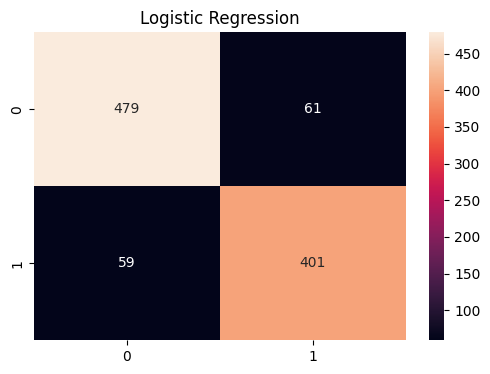

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression")

plt.show()

In [29]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

y_pred_dt = dt.predict(X_test)

In [30]:
print("Accuracy:",
      accuracy_score(y_test,y_pred_dt))

print("Precision:",
      precision_score(y_test,y_pred_dt))

print("Recall:",
      recall_score(y_test,y_pred_dt))

print("F1:",
      f1_score(y_test,y_pred_dt))

Accuracy: 0.864
Precision: 0.8389121338912134
Recall: 0.8717391304347826
F1: 0.8550106609808102


In [31]:
plt.figure(figsize=(60,40), dpi=300)

plot_tree(
    dt,
    feature_names=X.columns,
    filled=True
)

plt.show()
plt.savefig("decision_tree.pdf", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
11              Lead_Score    0.947051
12  Conversion_Probability    0.034972
8                      Lag    0.009435
9                      ELT    0.004372
3           Pitch_Category    0.002304
4            Pitch_Minutes    0.001218
5             Followup_Gap    0.000648
0                   Region    0.000000
2                Time_Slot    0.000000
1                   Course    0.000000
6              Script_Tone    0.000000
7                 Attempts    0.000000
10           Outreach_Type    0.000000


In [33]:
cluster_features = data[
[
    "Engagement_Score",
       "Lag",
    "Attempts",
    "Conversion_Probability"
]
]

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_features
)

In [35]:

inertia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(cluster_scaled)

    inertia.append(km.inertia_)

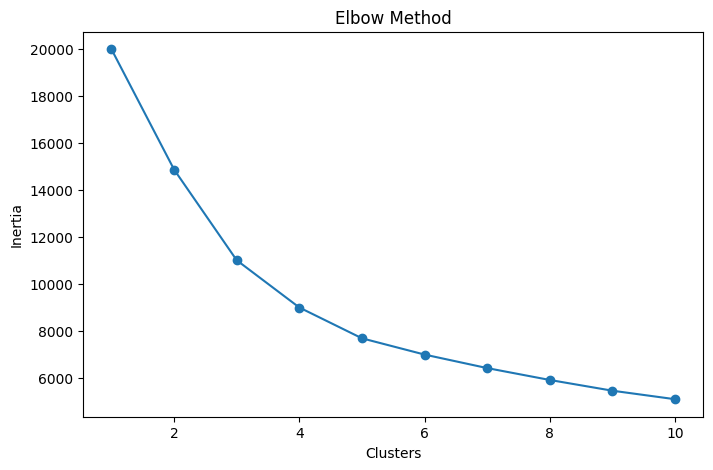

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [37]:
km = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = km.fit_predict(
    cluster_scaled
)

data["Cluster"] = clusters

In [38]:

score = silhouette_score(
    cluster_scaled,
    clusters
)

print("Silhouette Score:",score)

Silhouette Score: 0.2614017044239565


In [39]:
cluster_profile = data.groupby(
    "Cluster"
)[
[
    "Engagement_Score"

    
]
].mean()
probval=data.groupby("Cluster")["Conversion_Probability"].mean()/1000

print(cluster_profile)
print(probval)

         Engagement_Score
Cluster                  
0               69.388448
1               56.708972
2               58.545455
3               80.149849
Cluster
0    0.055099
1    0.044077
2    0.049773
3    0.063869
Name: Conversion_Probability, dtype: float64


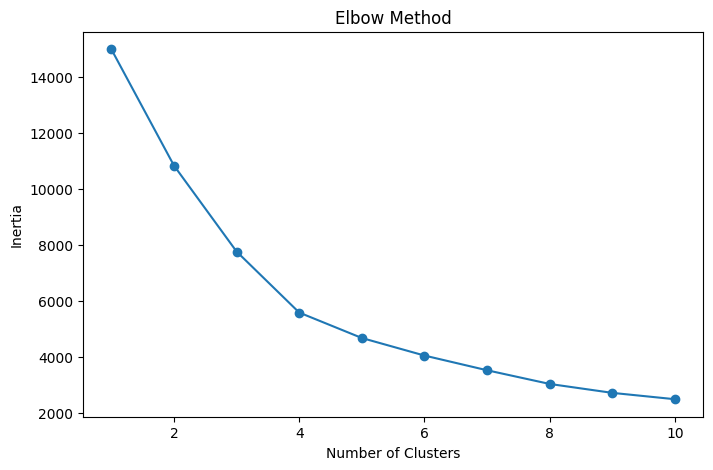


Silhouette Score: 0.32542069862045475

Cluster Distribution
Cluster
0    1674
1    1570
2     132
3    1624
Name: count, dtype: int64


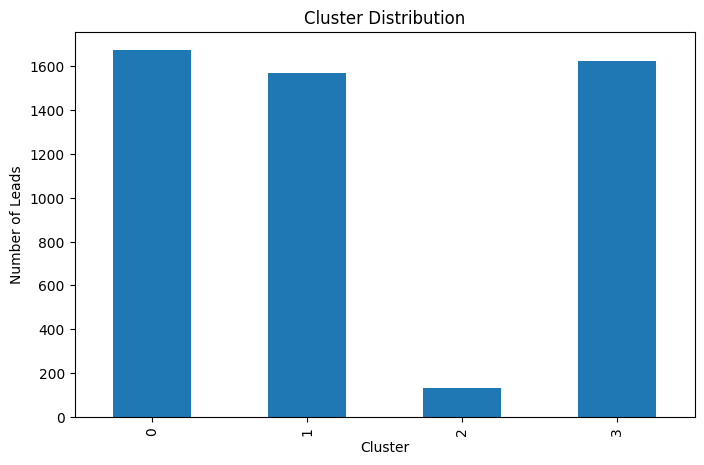


Cluster Profiles
         Engagement_Score       Lag  Attempts
Cluster                                      
0               57.146356  3.981720  1.040024
1               65.616561  7.358280  1.031210
2               58.545455  5.257576  3.371212
3               82.348522  4.640517  1.015394

Cluster Centers
   Engagement_Score       Lag  Attempts
0         57.132415  3.976753  1.040144
1         65.628010  7.351014  1.031686
2         58.545455  5.257576  3.371212
3         82.356570  4.637261  1.014806


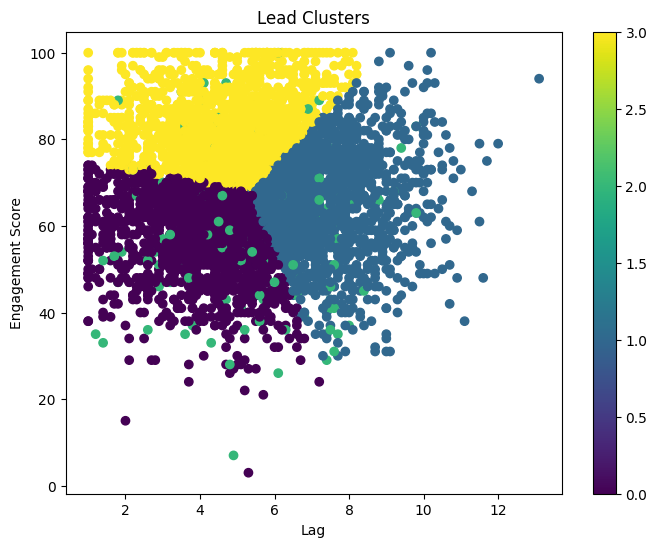

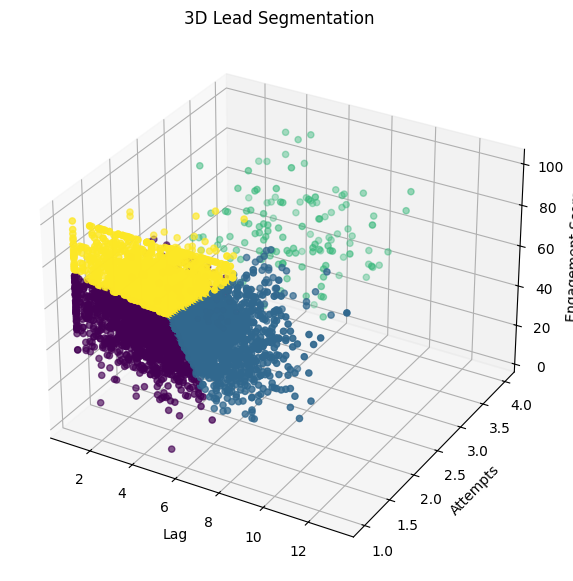

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

# ==========================
# SELECT CLUSTER VARIABLES
# ==========================

cluster_data = data[
    [
        "Engagement_Score",
        "Lag",
        "Attempts"
    ]
]

# ==========================
# STANDARDIZATION
# ==========================

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_data)

# ==========================
# ELBOW METHOD
# ==========================

inertia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# ==========================
# FINAL KMEANS
# ==========================

km = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = km.fit_predict(scaled)

data["Cluster"] = clusters

# ==========================
# SILHOUETTE SCORE
# ==========================

score = silhouette_score(
    scaled,
    clusters
)

print("\nSilhouette Score:", score)

# ==========================
# CLUSTER DISTRIBUTION
# ==========================

print("\nCluster Distribution")

print(
    data["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

data["Cluster"] \
    .value_counts() \
    .sort_index() \
    .plot(kind="bar")

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Leads")

plt.show()

# ==========================
# CLUSTER PROFILE
# ==========================

cluster_summary = data.groupby(
    "Cluster"
)[
    [
        "Engagement_Score",
        "Lag",
        "Attempts"
    ]
].mean()

print("\nCluster Profiles")

print(cluster_summary)

# ==========================
# CLUSTER CENTERS
# ==========================

centers = pd.DataFrame(
    scaler.inverse_transform(
        km.cluster_centers_
    ),
    columns=[
        "Engagement_Score",
        "Lag",
        "Attempts"
    ]
)

print("\nCluster Centers")

print(centers)

# ==========================
# 2D VISUALIZATION
# ==========================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    data["Lag"],
    data["Engagement_Score"],
    c=data["Cluster"]
)

plt.xlabel("Lag")
plt.ylabel("Engagement Score")
plt.title("Lead Clusters")

plt.colorbar(scatter)

plt.show()

# ==========================
# 3D VISUALIZATION
# ==========================

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(
    data["Lag"],
    data["Attempts"],
    data["Engagement_Score"],
    c=data["Cluster"]
)

ax.set_xlabel("Lag")
ax.set_ylabel("Attempts")
ax.set_zlabel("Engagement Score")

plt.title("3D Lead Segmentation")

plt.show()
